<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/LENET5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# data

In [ ]:
import tensorflow
from tensorflow import keras
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, AveragePooling2D

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

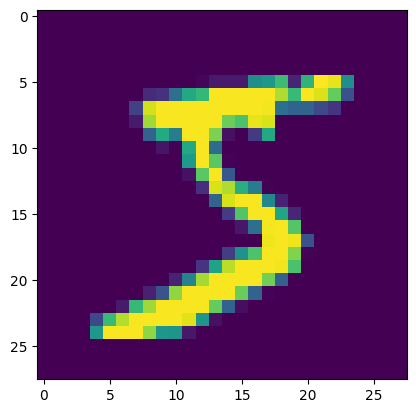

5


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.show()
print(y_train[0])

In [ ]:
X_train[0].shape

(28, 28)

# LENET5

In [ ]:
model = Sequential()

model.add(Conv2D(6,kernel_size = (5,5), padding = "valid", activation = "tanh", input_shape = (28, 28, 1))) # input shape = (28, 28, 1)
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = "valid"))

# model.add(Conv2D(6,kernel_size = (5,5), stride = (1,1), padding = "valid", activation = "tanh", input_shape = (28,28,1)))
# model.add(AveragePooling2D(pool_size = (2,2), stride = (2,2), padding = "valid"))

model.add(Conv2D(16,kernel_size = (5,5), padding = "valid", activation = "tanh")) # input shape = (24, 24, 32)
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = "valid"))

model.add(Flatten())

model.add(Dense(120, activation = "tanh"))
model.add(Dense(84, activation = "tanh"))
model.add(Dense(10, activation = "softmax"))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer = "Adam",loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
history = model.fit(X_train, y_train, epochs = 10, validation_data = (X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.9083 - loss: 0.3104 - val_accuracy: 0.9808 - val_loss: 0.0609
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9787 - loss: 0.0676 - val_accuracy: 0.9849 - val_loss: 0.0498
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9857 - loss: 0.0478 - val_accuracy: 0.9825 - val_loss: 0.0573
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9860 - val_loss: 0.0482
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9878 - val_loss: 0.0396
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9861 - val_loss: 0.0413
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9860 - val_loss: 0.0416
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9926 -

# eval

In [ ]:
y_hat = (model.predict(X_test)).argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_hat)

0.9888

In [ ]:
# MLP had accuracy of 0.9771

In [ ]:
print(f"predicted: {y_hat[0]:6.0f} actual: {y_test[0]:6.0f}")

predicted:      7 actual:      7


**WAYS TO IMPROVE -**

 - activation - relu
 - batch norm
 - dropout
 - more epochs & early stopping
 - lr scheduling and optimizer checking using keras-tuner
 - more hyperparameter tuning using keras-tuner



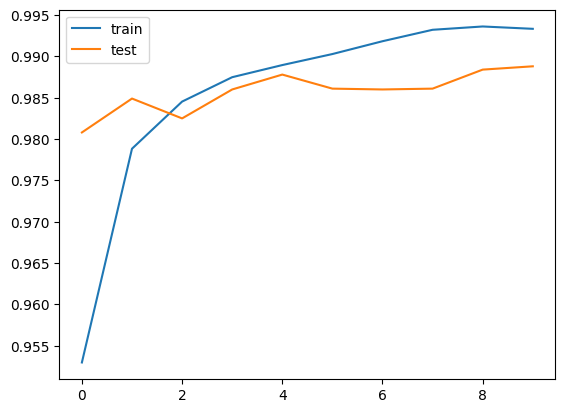

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train", "test"])
plt.show()

# Extras
**TODO -**

1. CNN from scratch
2. maybe visualize the middle layers
3. try different archs

## visualizing filters -

In [ ]:
weights = model.get_weights()
for i in range(len(weights)):
    print(weights[i].shape)

(5, 5, 1, 6)
(6,)
(5, 5, 6, 16)
(16,)
(256, 120)
(120,)
(120, 84)
(84,)
(84, 10)
(10,)




```
(5, 5, 1, 6) -------- layer 1 weights
(6,) ---------------- layer 1 biases
(5, 5, 6, 16) ------- layer 2 w
(16,) --------------- layer 2 b
(256, 120) ---------- layer 3 w (fully connected)
(120,) -------------- layer 3 b
(120, 84) ----------- layer 4 w
(84,)  -------------- layer 4 b
(84, 10) ------------ layer 5 w
(10,) --------------- layer 5 b
```



In [ ]:
type(weights[1])

numpy.ndarray

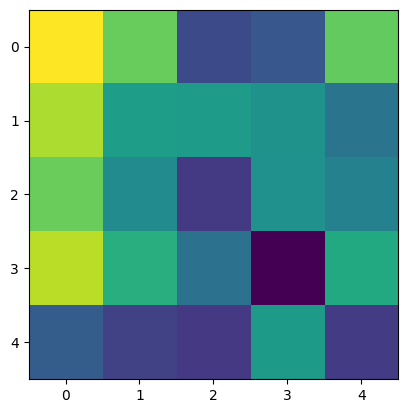

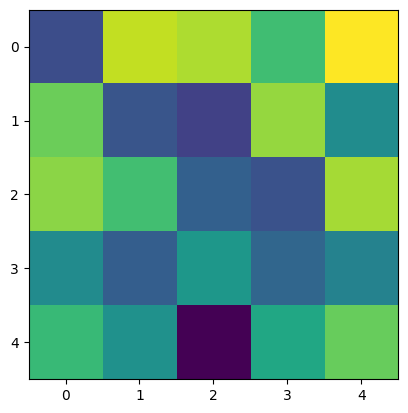

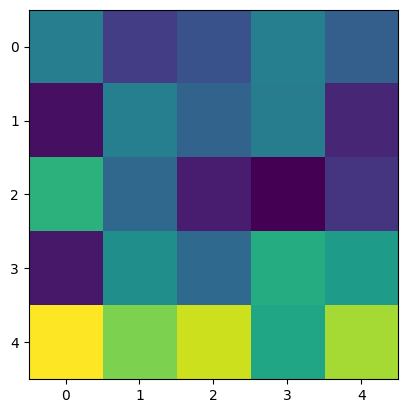

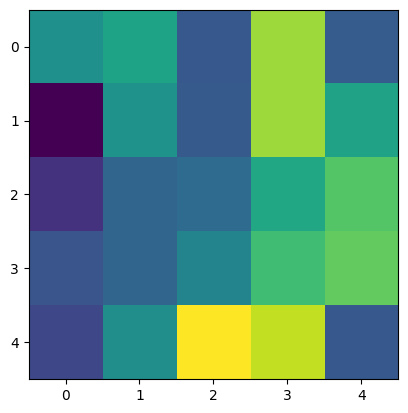

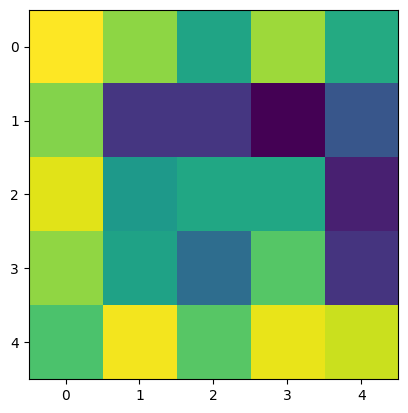

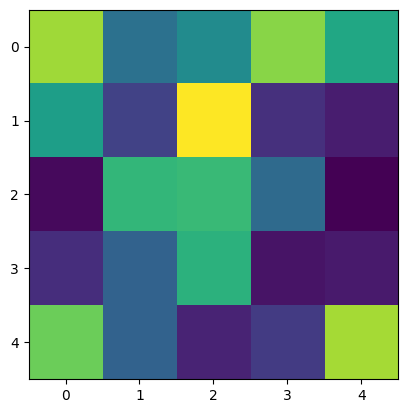

In [ ]:
# layer 1 filters
for i in range(6):
  for j in range(1):
    # plt.imshow(weights[0][:,:,j,i]+weights[1][i])
    plt.imshow(weights[0][:,:,j,i])
    plt.show()

In [ ]:
# # layer 2 filters
# for i in range(16):
#   for j in range(6):
#     plt.imshow(weights[2][:,:,j,i])
#     plt.show()

## visualizing intermediate images (features)

In [ ]:
# Get the output of the first convolutional layer
intermediate_layer_model = Sequential()
for layer in model.layers[:2]: # Include up to the first AveragePooling2D layer
    intermediate_layer_model.add(layer)

intermediate_output = intermediate_layer_model.predict(X_test[3].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


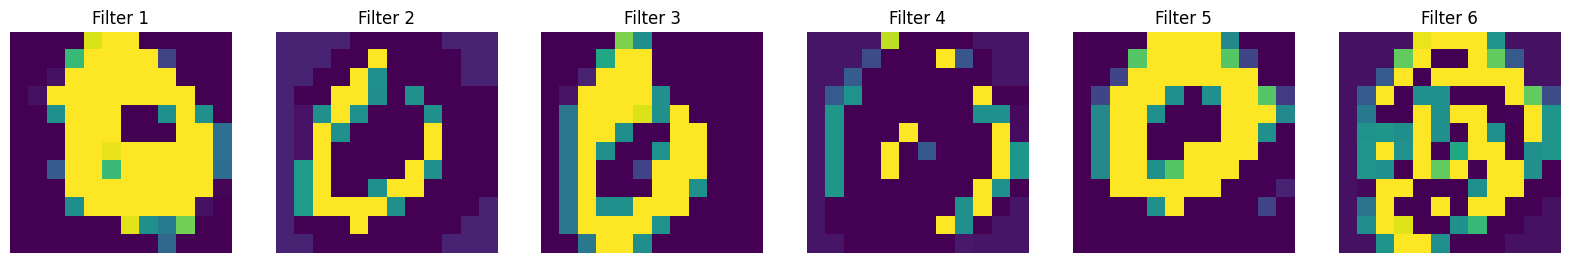

In [ ]:
# Visualize the output of each filter in the first convolutional layer
fig, axes = plt.subplots(1, intermediate_output.shape[-1], figsize=(20, 5))
for i in range(intermediate_output.shape[-1]):
    # To show only positive edges, use: cmap='viridis' , vmin=0
    # To show only negative edges, use: cmap='plasma' , vmax=0
    axes[i].imshow(intermediate_output[0, :, :, i], cmap='viridis', vmin=0)
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')
plt.show()

In [ ]:
# Get the output of the first convolutional layer
intermediate_layer_model = Sequential()
for layer in model.layers[:4]: # Include up to the second AveragePooling2D layer (Conv2D, AvgPool2D, Conv2D, AvgPool2D)
    intermediate_layer_model.add(layer)

intermediate_output = intermediate_layer_model.predict(X_test[3].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


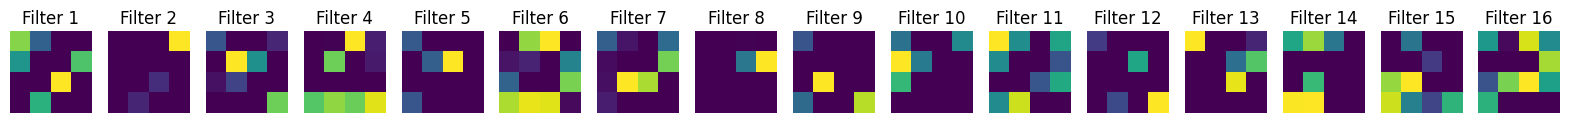

In [ ]:
# Visualize the output of each filter in the second convolutional layer
fig, axes = plt.subplots(1, intermediate_output.shape[-1], figsize=(20, 10)) # Adjusted figsize for more filters
for i in range(intermediate_output.shape[-1]):
    # To show only positive edges, use: cmap='viridis' , vmin=0
    # To show only negative edges, use: cmap='plasma' , vmax=0
    axes[i].imshow(intermediate_output[0, :, :, i], cmap='viridis', vmin=0)
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')
plt.show()